In [24]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
tickers = ['NVDA', 'QQQ', 'PLTR', 'DANHOS13.MX', 'GOOG']

In [3]:
prices = yf.download(tickers, start='2020-01-01', end='2026-08-24')['Close']

[*********************100%***********************]  5 of 5 completed


In [4]:
prices

Ticker,DANHOS13.MX,GOOG,NVDA,PLTR,QQQ
Date,,,,,
2020-01-02,17.197742,67.770988,5.963804,NaN,208.088806
2020-01-03,17.109243,67.438423,5.868348,NaN,206.182816
2020-01-06,17.103346,69.101265,5.892956,NaN,207.511292
2020-01-07,17.056145,69.058136,5.964300,NaN,207.482391
2020-01-08,16.867353,69.602333,5.975487,NaN,209.041885
...,...,...,...,...,...
2026-08-17,28.469999,341.450012,225.009995,172.550003,729.869995
2026-08-18,28.260000,341.279999,219.740005,171.539993,717.510010
2026-08-19,28.450001,341.700012,217.559998,175.190002,716.080017


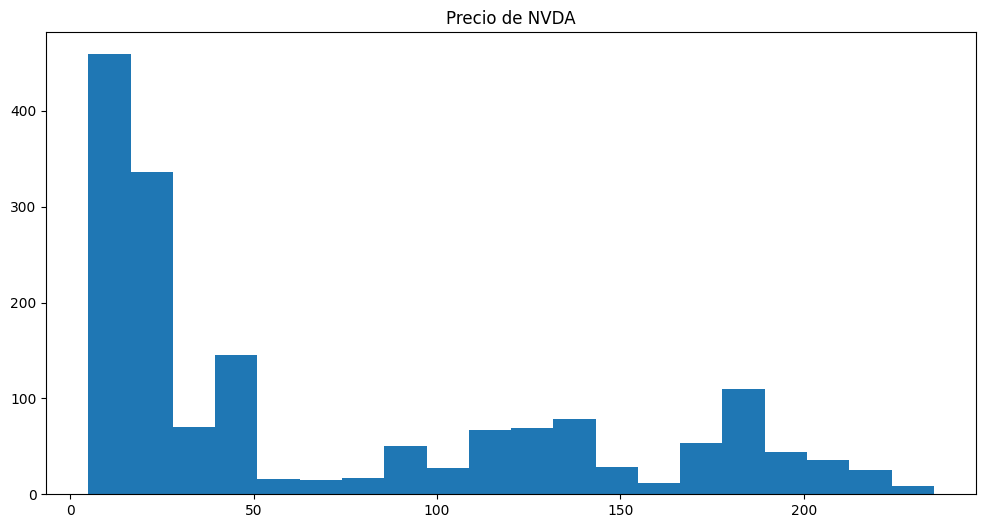

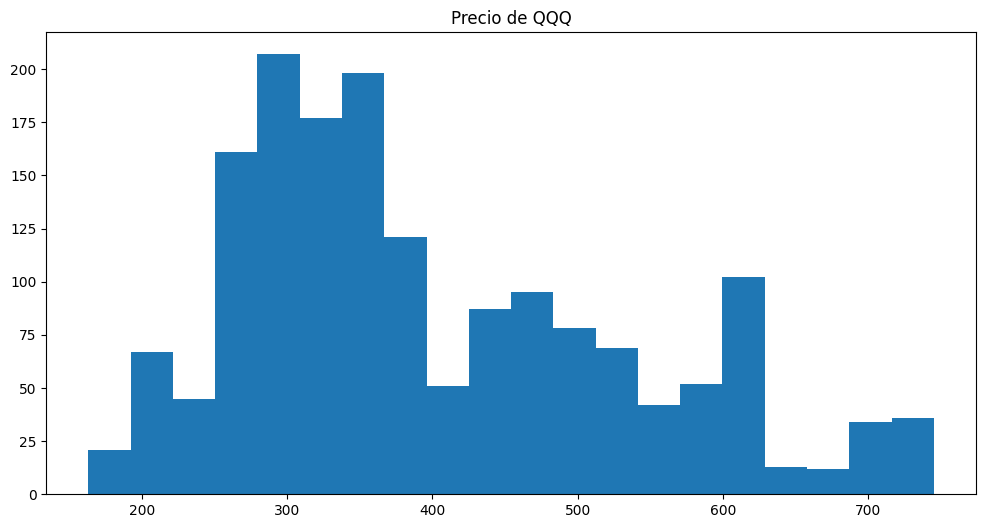

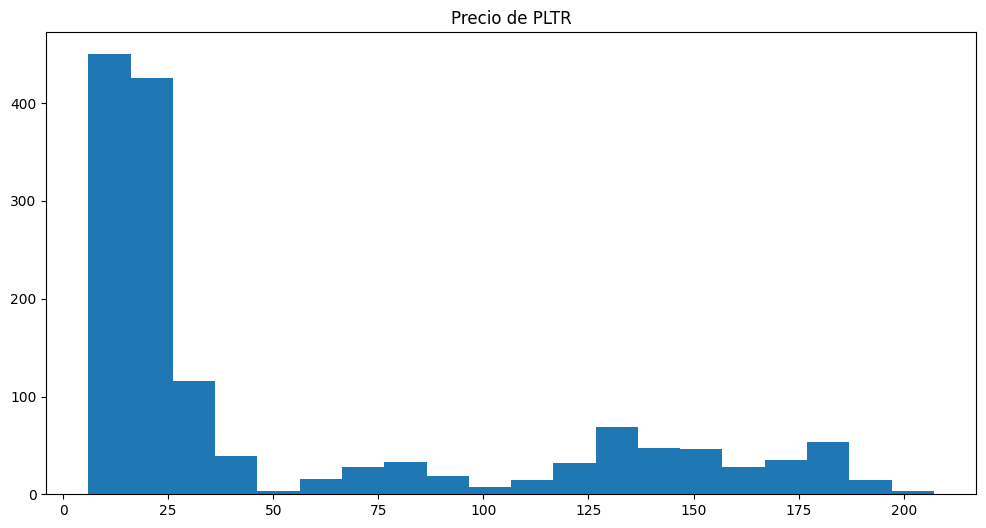

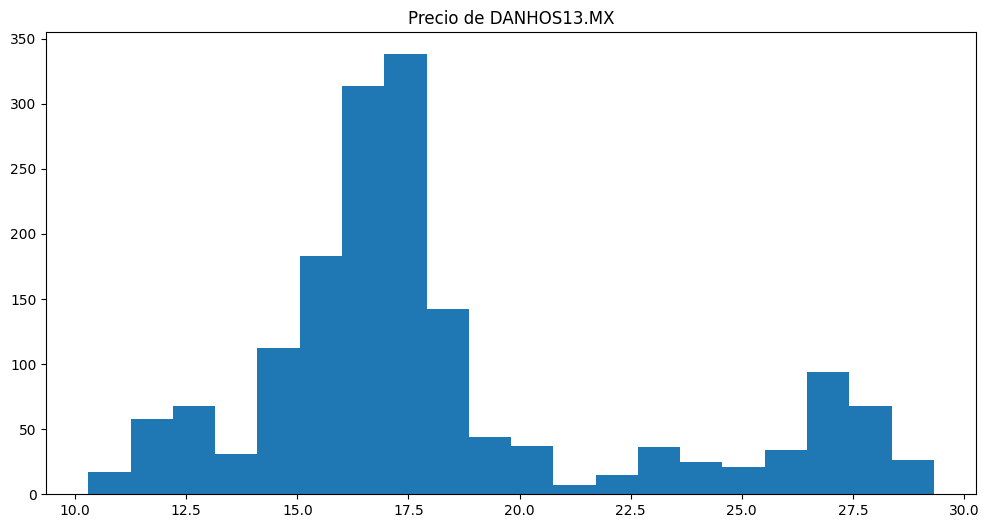

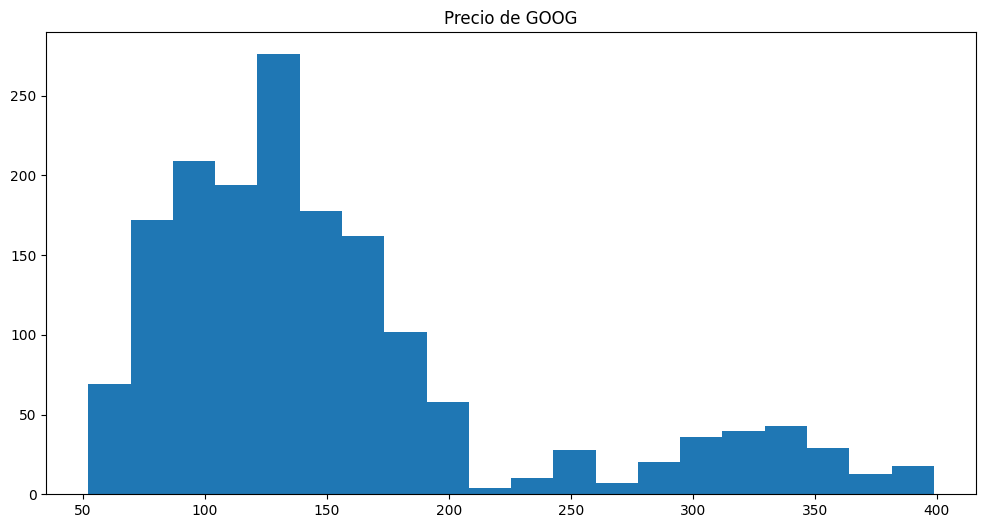

In [5]:
for ticker in tickers:
    plt.figure(figsize=(12, 6))
    plt.hist(prices[ticker], label=ticker, bins=20)
    plt.title(f'Precio de {ticker}')
    plt.show()

No se puede usar el precio para modelar el comportamiento futuro de una acción sin hacer transformaciones

Lo que sí podemos usar es el rendimiento $$R = (P_t - P_0) / P_0$$ o $$R = (P_t / P_0) - 1$$

In [6]:
prices

Ticker,DANHOS13.MX,GOOG,NVDA,PLTR,QQQ
Date,,,,,
2020-01-02,17.197742,67.770988,5.963804,NaN,208.088806
2020-01-03,17.109243,67.438423,5.868348,NaN,206.182816
2020-01-06,17.103346,69.101265,5.892956,NaN,207.511292
2020-01-07,17.056145,69.058136,5.964300,NaN,207.482391
2020-01-08,16.867353,69.602333,5.975487,NaN,209.041885
...,...,...,...,...,...
2026-08-17,28.469999,341.450012,225.009995,172.550003,729.869995
2026-08-18,28.260000,341.279999,219.740005,171.539993,717.510010
2026-08-19,28.450001,341.700012,217.559998,175.190002,716.080017


Calculamos rendimiento

In [ ]:
prices.shift() # Desplazamiento de los precios para calcular el rendimiento

Ticker,DANHOS13.MX,GOOG,NVDA,PLTR,QQQ
Date,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN
2020-01-03,17.197742,67.770988,5.963804,NaN,208.088806
2020-01-06,17.109243,67.438423,5.868348,NaN,206.182816
2020-01-07,17.103346,69.101265,5.892956,NaN,207.511292
2020-01-08,17.056145,69.058136,5.964300,NaN,207.482391
...,...,...,...,...,...
2026-08-17,28.309999,343.540009,225.160004,174.039993,731.070007
2026-08-18,28.469999,341.450012,225.009995,172.550003,729.869995
2026-08-19,28.260000,341.279999,219.740005,171.539993,717.510010


In [8]:
daily_rets = prices / prices.shift() - 1
daily_rets

Ticker,DANHOS13.MX,GOOG,NVDA,PLTR,QQQ
Date,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN
2020-01-03,-0.005146,-0.004907,-0.016006,NaN,-0.009160
2020-01-06,-0.000345,0.024657,0.004193,NaN,0.006443
2020-01-07,-0.002760,-0.000624,0.012107,NaN,-0.000139
2020-01-08,-0.011069,0.007880,0.001876,NaN,0.007516
...,...,...,...,...,...
2026-08-17,0.005652,-0.006084,-0.000666,-0.008561,-0.001641
2026-08-18,-0.007376,-0.000498,-0.023421,-0.005853,-0.016935
2026-08-19,0.006723,0.001231,-0.009921,0.021278,-0.001993


Eliminamos nulos

In [9]:
daily_rets = daily_rets.dropna() # Eliminación de valores nulos
daily_rets

Ticker,DANHOS13.MX,GOOG,NVDA,PLTR,QQQ
Date,,,,,
2020-10-01,-0.024679,0.013942,0.006208,-0.004211,0.015872
2020-10-02,0.026316,-0.021254,-0.040563,-0.027484,-0.028131
2020-10-05,0.012328,0.018925,0.044422,-0.018478,0.021326
2020-10-06,-0.010229,-0.021925,0.006890,0.096346,-0.017847
2020-10-07,0.037402,0.004713,0.016562,0.010101,0.017299
...,...,...,...,...,...
2026-08-17,0.005652,-0.006084,-0.000666,-0.008561,-0.001641
2026-08-18,-0.007376,-0.000498,-0.023421,-0.005853,-0.016935
2026-08-19,0.006723,0.001231,-0.009921,0.021278,-0.001993


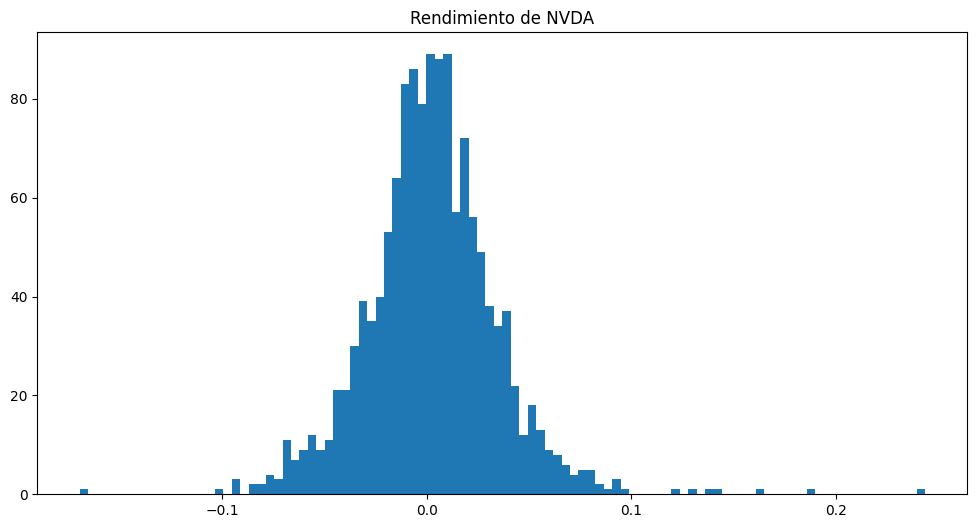

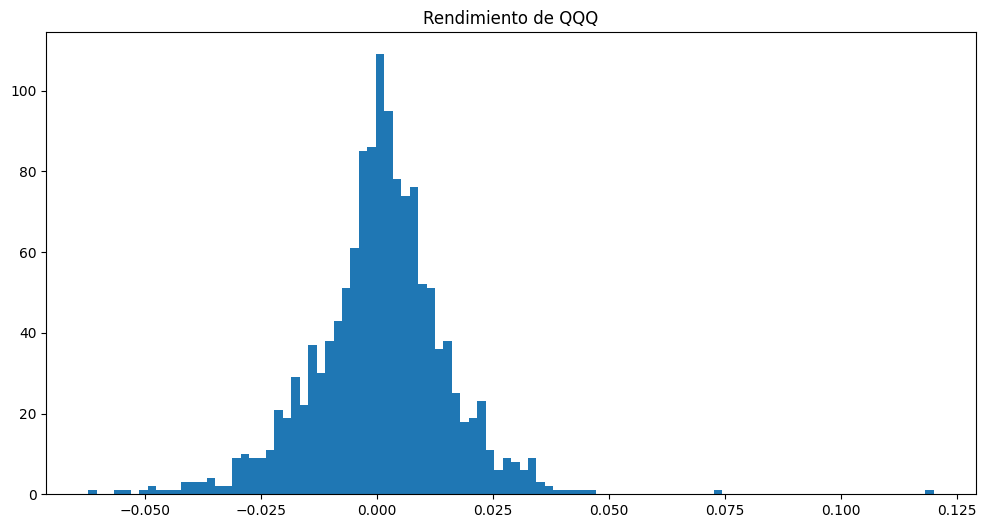

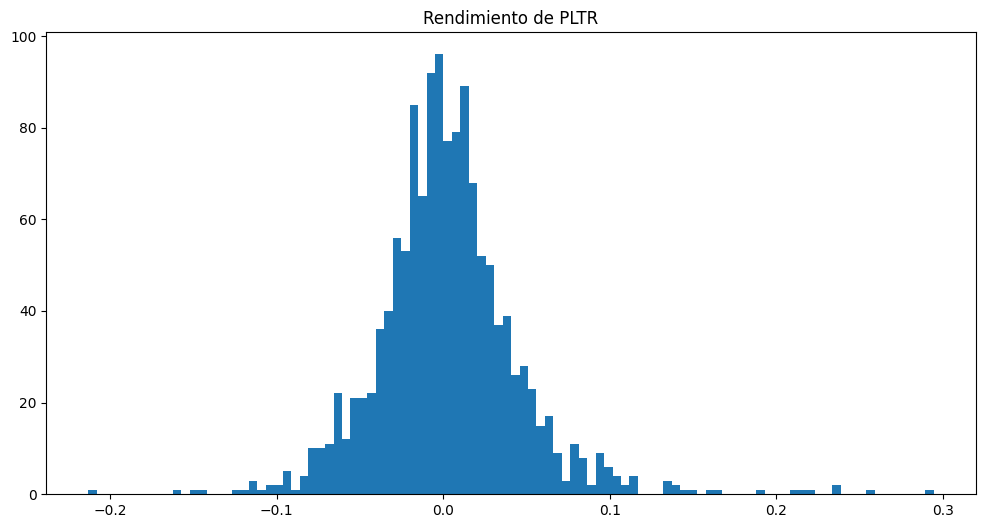

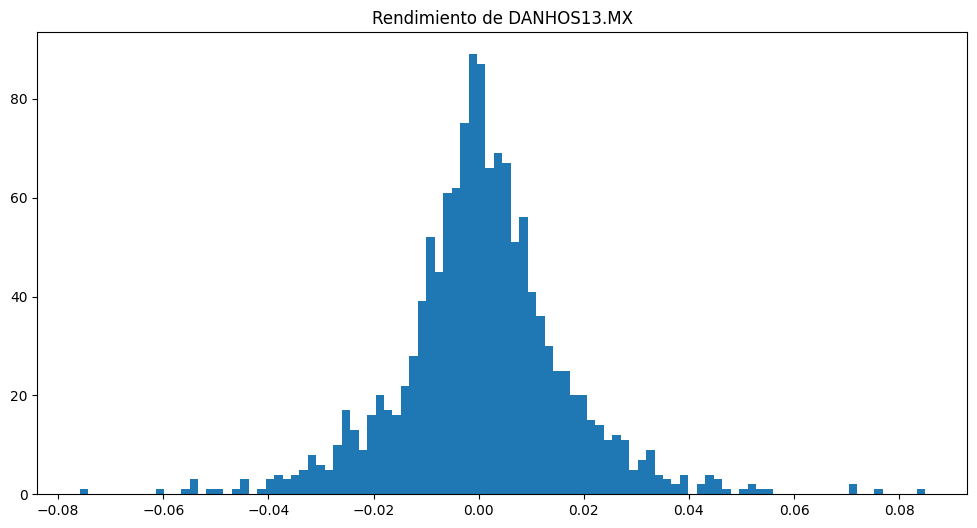

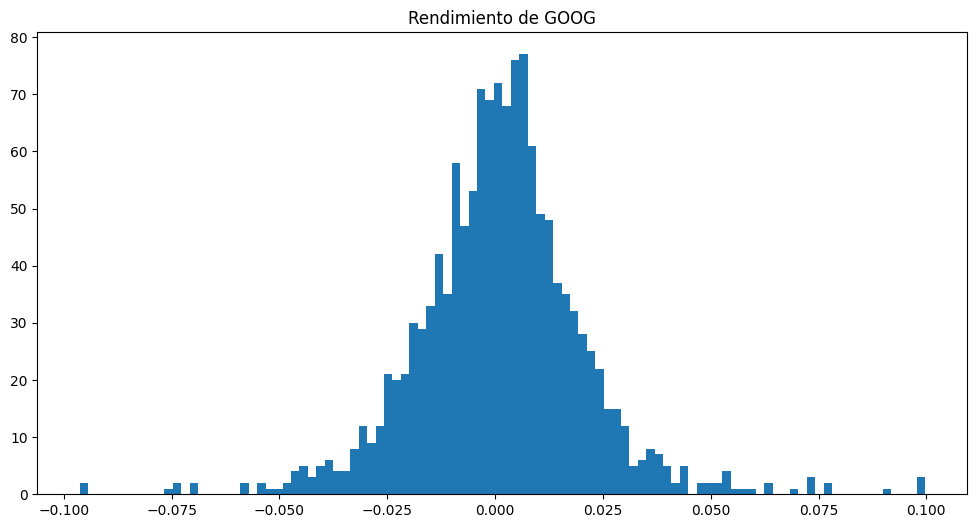

In [11]:
for ticker in tickers:
    plt.figure(figsize=(12, 6))
    plt.hist(daily_rets[ticker], label=ticker, bins=100)
    plt.title(f'Rendimiento de {ticker}')
    plt.show()

Los rendimientos diarios tienden a una media igual a 0. 

Y la asimetría y la curtósis difieren en cada una, pero tienden a una distribución normal.

En finanzas buscamos una asimetría positiva.

Pero la pregunta es, ¿cómo medimos el rendimiento esperado y el riesgo?

**Si el promedio de los rendimientos de un activo es $x$, significa que una inversión en el largo paso, tiende a un rendimiento de $x$.**

En el corto plazo, factores exógenos afectan al rendimiento del activo, pero en el largo plazo, los rendimientos tienden a la media.

In [12]:
daily_mean = daily_rets.mean()
daily_mean

Ticker
DANHOS13.MX    0.000649
GOOG           0.001147
NVDA           0.002484
PLTR           0.002683
QQQ            0.000728
dtype: float64

In [13]:
# Porcentaje
daily_mean * 100

Ticker
DANHOS13.MX    0.064897
GOOG           0.114677
NVDA           0.248415
PLTR           0.268289
QQQ            0.072793
dtype: float64

Para anualizar el rendimiento, usamos el estándar del mercado, que son 252 días

In [14]:
anual_mean = daily_mean * 252
anual_mean

Ticker
DANHOS13.MX    0.163540
GOOG           0.288986
NVDA           0.626006
PLTR           0.676088
QQQ            0.183437
dtype: float64

In [15]:
anual_mean * 100

Ticker
DANHOS13.MX    16.354031
GOOG           28.898559
NVDA           62.600618
PLTR           67.608815
QQQ            18.343728
dtype: float64

**Nunca se evalúa una inversión por sí sola solo con el rendimiento**

También hay que evaluar el riesgo (varianza con respecto al valor esperado).

Desviación estándar = Volatilidad

El riesgo es la posibilidad de que se produzca un resultado distinto al esperado, pero en realidad no sabemos lo que va a pasar (**incertidumbre**).

In [16]:
daily_variance = daily_rets.var()
daily_variance

Ticker
DANHOS13.MX    0.000250
GOOG           0.000386
NVDA           0.001032
PLTR           0.001884
QQQ            0.000207
dtype: float64

In [ ]:
anual_variance = daily_variance * 252
anual_variance 

Ticker
DANHOS13.MX    0.063083
GOOG           0.097287
NVDA           0.259998
PLTR           0.474878
QQQ            0.052162
dtype: float64

In [18]:
anual_variance * 100

Ticker
DANHOS13.MX     6.308251
GOOG            9.728687
NVDA           25.999846
PLTR           47.487764
QQQ             5.216215
dtype: float64

Pero las unidades de la varianza no se puden interpretar, por eso casi no tiene uso en las finanzas. Lo que sí se usa es la desviación estándar.

In [19]:
daily_vol = daily_rets.std()
daily_vol

Ticker
DANHOS13.MX    0.015822
GOOG           0.019648
NVDA           0.032121
PLTR           0.043410
QQQ            0.014387
dtype: float64

In [20]:
daily_vol * 100

Ticker
DANHOS13.MX    1.582174
GOOG           1.964838
NVDA           3.212071
PLTR           4.341008
QQQ            1.438724
dtype: float64

Para el valor esperado con un 99% de confianza:

Significa lo que podrías ganar o perder en un solo día con cada activo.

In [ ]:
(daily_mean - 3*daily_vol)*100, (daily_mean + 3*daily_vol)*100

(Ticker
 DANHOS13.MX    -4.681625
 GOOG           -5.779839
 NVDA           -9.387797
 PLTR          -12.754735
 QQQ            -4.243379
 dtype: float64,
 Ticker
 DANHOS13.MX     4.811419
 GOOG            6.009192
 NVDA            9.884628
 PLTR           13.291313
 QQQ             4.388964
 dtype: float64)

Para anualizar la volatilidad

In [26]:
anual_vol = daily_vol * np.sqrt(252)
anual_vol

Ticker
DANHOS13.MX    0.251162
GOOG           0.311908
NVDA           0.509900
PLTR           0.689114
QQQ            0.228390
dtype: float64

Coef. de variación

Cuántas unidades de riesgo asumes por unidad de rendimiento.

No dice que el riesgo sea menor, solo que paga más.

In [28]:
CV = anual_vol / anual_mean
CV 

Ticker
DANHOS13.MX    1.535782
GOOG           1.079322
NVDA           0.814529
PLTR           1.019266
QQQ            1.245060
dtype: float64

In [29]:
anual_vol, anual_mean

(Ticker
 DANHOS13.MX    0.251162
 GOOG           0.311908
 NVDA           0.509900
 PLTR           0.689114
 QQQ            0.228390
 dtype: float64,
 Ticker
 DANHOS13.MX    0.163540
 GOOG           0.288986
 NVDA           0.626006
 PLTR           0.676088
 QQQ            0.183437
 dtype: float64)

Calculamos ahora, la asimetría

Existen 3 tipos de asimetría:

`.skew()` puede dar 3 posibles valores:

1. skew = 0: Simétrico

2. skew < 0: Asimetría negativa (outliers cargados a las pérdidas) Malo porque es más probable tener una pérdida atípica y mayor que una ganancia atípica.

3. skew > 0: Asimetría positiva (outliers cargados a las ganancias) Bueno porque es más probable tener una ganancia atípica.

**Ojo**: Sí podemos saber cuál activo es más asimétrico en base al valor absoluto, pero el valor no se puede interpretar la magnitud.

In [30]:
daily_rets.skew()

Ticker
DANHOS13.MX    0.153438
GOOG           0.172823
NVDA           0.532569
PLTR           0.918041
QQQ            0.171463
dtype: float64

La asimetría por sí sola no sirve para ver qué activo es mejor, ya que valores atípicos pueden afectar a la métrica.

Importan estos 3 momentos:

1. Valor esperado
2. Volatilidad
3. Asimetría/Sesgo

En finanzas, el precio no se puede trabajar por sí solo, se usa el rendimiento diario porque sigue una distribución normal.

El valor esperado es la media, la volatilidad es la desv estándar y la varianza (riesgo) es la dispersión de los datos con respecto a la media.